In [1]:
# Make the repo importable from this notebook (it lives in <repo>/jupyternotebooks) and provide what
# `source setup.sh` would give a shell: Jupyter kernels do not source it.
import os, sys
from pathlib import Path

REPO = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "setup.sh").is_file()),
    Path("/global/homes/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae"),
)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# configs/file_dict.py needs LOCAL_BASE_DIR; take it from setup.sh if the kernel does not have it
if "LOCAL_BASE_DIR" not in os.environ:
    for line in (REPO / "setup.sh").read_text().splitlines():
        if line.startswith("export LOCAL_BASE_DIR="):
            os.environ["LOCAL_BASE_DIR"] = line.split("=", 1)[1].strip().strip('"').strip("'")

print("repo:", REPO, "\nLOCAL_BASE_DIR:", os.environ["LOCAL_BASE_DIR"])

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.processing import process_delphes_events, build_arrays, presence_mask
from src.processing import compute_normalization, apply_normalization, invert_normalization, build_interaction_norm

repo: /global/u2/m/mukyu/Misc/Invertible_eocnder/particle_transformer_ae 
LOCAL_BASE_DIR: /pscratch/sd/d/dnoll/projects/haxad/EventGenDelphes/output/


In [2]:
num_events_per_process=50000

nonres_yy_jjj = process_delphes_events("nonres_yy_jjj", num_events_per_process=num_events_per_process)
ggh_yy = process_delphes_events("ggh_yy", num_events_per_process=num_events_per_process)
vbf_yy = process_delphes_events("vbf_yy", num_events_per_process=num_events_per_process)
vh_yy = process_delphes_events("vh_yy", num_events_per_process=num_events_per_process)
ttH_yy = process_delphes_events("ttH_yy", num_events_per_process=num_events_per_process)
WN_HyyN_150 = process_delphes_events("WN_HyyN_150", num_events_per_process=num_events_per_process)
WN_HyyN_200 = process_delphes_events("WN_HyyN_200", num_events_per_process=num_events_per_process)
WN_HyyN_600 = process_delphes_events("WN_HyyN_600", num_events_per_process=num_events_per_process)

combined_df = pd.concat([nonres_yy_jjj, ggh_yy, vbf_yy, vh_yy, ttH_yy, WN_HyyN_150, WN_HyyN_200, WN_HyyN_600], ignore_index=True)

# shuffle the combined dataframe to avoid any ordering bias
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# particle_level (n, 13, 7), kin_raw (n, 13, 4), process_id (n,), event_weight (n,); pair features are built per batch from kin_raw
arrays = build_arrays(combined_df)

normalization_params = compute_normalization(arrays)
arrays_normalized = apply_normalization(arrays, normalization_params)

In [3]:
arrays_normalized.keys()

dict_keys(['particle_level', 'kin_raw', 'process_id', 'event_weight'])

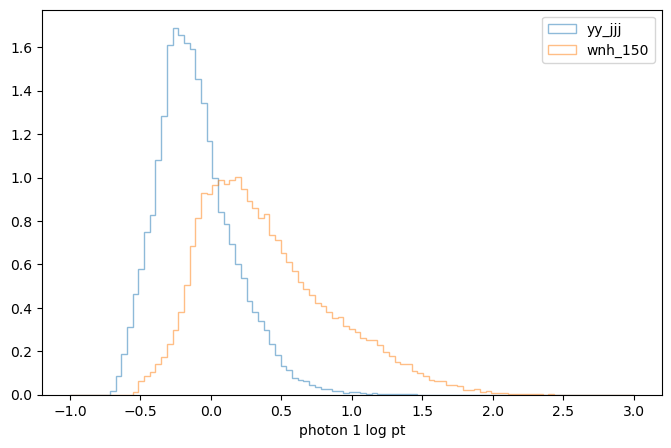

In [4]:
f = plt.figure(figsize=(8, 5))
bins = np.linspace(-1, 3, 100)
mask_yy_jjj = arrays_normalized["process_id"] == 1
plt.hist(arrays_normalized["particle_level"][mask_yy_jjj, 0, 0], bins=bins, alpha=0.5, label="yy_jjj", histtype="step", density=True)
mask_wnh_150 = arrays_normalized["process_id"] == -1
plt.hist(arrays_normalized["particle_level"][mask_wnh_150, 0, 0], bins=bins, alpha=0.5, label="wnh_150", histtype="step", density=True)
plt.legend()
plt.xlabel("photon 1 log pt")
plt.show()

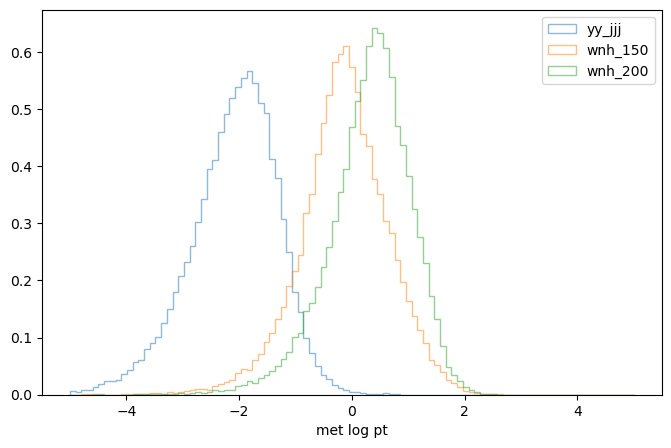

In [5]:
f = plt.figure(figsize=(8, 5))
bins = np.linspace(-5, 5, 100)
mask_yy_jjj = arrays_normalized["process_id"] == 1
plt.hist(arrays_normalized["particle_level"][mask_yy_jjj, -1, 0], bins=bins, alpha=0.5, label="yy_jjj", histtype="step", density=True)
mask_wnh_150 = arrays_normalized["process_id"] == -1
plt.hist(arrays_normalized["particle_level"][mask_wnh_150, -1, 0], bins=bins, alpha=0.5, label="wnh_150", histtype="step", density=True)
mask_wnh_200 = arrays_normalized["process_id"] == -2
plt.hist(arrays_normalized["particle_level"][mask_wnh_200, -1, 0], bins=bins, alpha=0.5, label="wnh_200", histtype="step", density=True)
plt.legend()
plt.xlabel("met log pt")
plt.show()

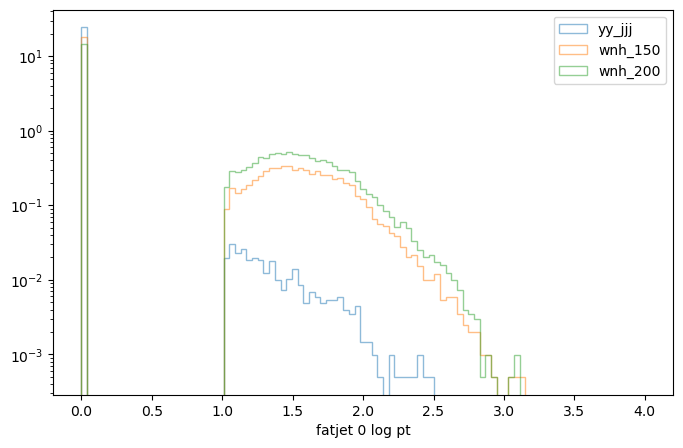

In [6]:
f = plt.figure(figsize=(8, 5))
bins = np.linspace(0,4, 100)
mask_yy_jjj = arrays_normalized["process_id"] == 1
plt.hist(arrays_normalized["particle_level"][mask_yy_jjj, 6, 0], bins=bins, alpha=0.5, label="yy_jjj", histtype="step", density=True)
mask_wnh_150 = arrays_normalized["process_id"] == -1
plt.hist(arrays_normalized["particle_level"][mask_wnh_150, 6, 0], bins=bins, alpha=0.5, label="wnh_150", histtype="step", density=True)
mask_wnh_200 = arrays_normalized["process_id"] == -2
plt.hist(arrays_normalized["particle_level"][mask_wnh_200, 6, 0], bins=bins, alpha=0.5, label="wnh_200", histtype="step", density=True)
plt.legend()
plt.xlabel("fatjet 0 log pt")
plt.yscale("log")
plt.show()

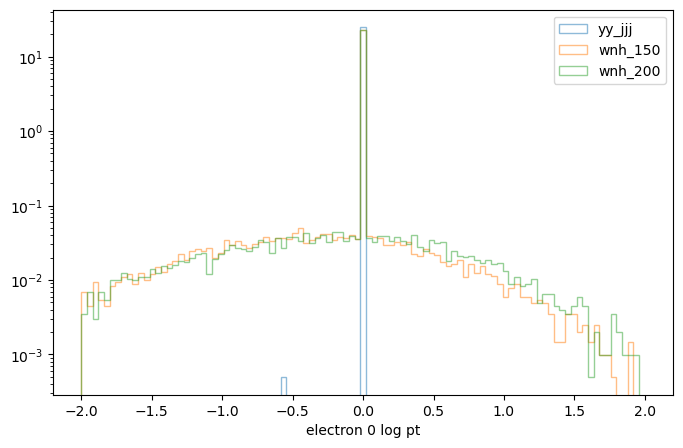

In [7]:
f = plt.figure(figsize=(8, 5))
bins = np.linspace(-2,2, 100)
mask_yy_jjj = arrays_normalized["process_id"] == 1
plt.hist(arrays_normalized["particle_level"][mask_yy_jjj, 8, 0], bins=bins, alpha=0.5, label="yy_jjj", histtype="step", density=True)
mask_wnh_150 = arrays_normalized["process_id"] == -1
plt.hist(arrays_normalized["particle_level"][mask_wnh_150, 8, 0], bins=bins, alpha=0.5, label="wnh_150", histtype="step", density=True)
mask_wnh_200 = arrays_normalized["process_id"] == -2
plt.hist(arrays_normalized["particle_level"][mask_wnh_200, 8, 0], bins=bins, alpha=0.5, label="wnh_200", histtype="step", density=True)
plt.legend()
plt.xlabel("electron 0 log pt")
plt.yscale("log")
plt.show()

In [8]:
from src.model.dpt_model import DPTDataSet, DPTModel, GpuBatchLoader

In [9]:
dataset = DPTDataSet(
    particle_level=arrays_normalized["particle_level"],
    kin_raw=arrays_normalized["kin_raw"],                           # raw pt, eta, phi, m: the pair features are built per batch from these
    mask_data=presence_mask(arrays_normalized["particle_level"]),   # 1 where the object exists
    label=arrays_normalized["process_id"],
    device="cuda" if torch.cuda.is_available() else "cpu",
    interaction_norm=build_interaction_norm(normalization_params),  # [(type, mean, std), ...] applied to the pair features per batch
)

dataloader = GpuBatchLoader(dataset, batch_size=32, shuffle=True)   # whole-batch gather on the device; torch DataLoader is 30-500x slower here

In [10]:
LATENT_DIM = 8
NUM_SELF_ATTN_LAYERS = 4
NUM_CLASS_ATTN_LAYERS = 2
NUM_HEADS = 8
EXPANSION = 3
DROP_RATE = 0.1
STOCHASTIC_DEPTH_DROP_RATE = 0.1
EMBEDDING_DIM = 128
CONV_EMBED_LATENT_DIM = 128
NUM_CONV_LAYERS = 2
NUM_EMBEDDING_LAYERS = 2
LAYER_SCALE_INI_VAL = 1e-4

NUM_PARTICLES = arrays_normalized["particle_level"].shape[1]
NUM_PARTICLE_FEATURES = arrays_normalized["particle_level"].shape[2]
NUM_INTERACTION_FEATURES = 6
INPUT_SHAPE =     (
    (NUM_PARTICLES, NUM_PARTICLE_FEATURES),
    (NUM_PARTICLES, NUM_PARTICLES, NUM_INTERACTION_FEATURES),
)


encoder_model = DPTModel(
    input_shape=INPUT_SHAPE,
    latent_dim=LATENT_DIM,
    num_self_attn_layers=NUM_SELF_ATTN_LAYERS,
    num_class_attn_layers=NUM_CLASS_ATTN_LAYERS,
    num_heads=NUM_HEADS,
    expansion=EXPANSION,
    layer_scale_ini_val=LAYER_SCALE_INI_VAL,
    drop_rate=DROP_RATE,
    stochastic_depth_drop_rate=STOCHASTIC_DEPTH_DROP_RATE,
    embedding_dim=EMBEDDING_DIM,
    num_embeding_layers=NUM_EMBEDDING_LAYERS,
    conv_embed_latent_dim=CONV_EMBED_LATENT_DIM,
    num_conv_layers=NUM_CONV_LAYERS,
    use_rmsnorm=False,
    use_qknorm=False,
    interaction_norm_type="layernorm",
)

encoder_model.to("cuda" if torch.cuda.is_available() else "cpu")

DPTModel(
  (node_embedding): FCEmbedding(
    (fc): Sequential(
      (0): Linear(in_features=7, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): GELU(approximate='none')
    )
  )
  (interaction_embedding): CNNEmbedding(
    (conv_layers): ModuleList(
      (0): Conv1d(6, 128, kernel_size=(1,), stride=(1,))
      (1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
      (2): Conv1d(128, 8, kernel_size=(1,), stride=(1,))
    )
    (norm_layers): ModuleList(
      (0-1): 2 x ChannelLayerNorm1d(
        (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (2): ChannelLayerNorm1d(
        (ln): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      )
    )
    (activation): GELU(approximate='none')
  )
  (self_attn_layer): SelfAttnDeParT(
    (self_attn_blocks): ModuleList(
      (0-3): 4 x SelfAttentionBlock(
        (pre_mhsa_ln): LayerNorm((128,), eps=1e-05, elementwise_

In [ ]:
for batch in dataloader:
    particle_level, interaction, mask, label = batch
    output, presence, z = encoder_model((particle_level, interaction, mask))
    print("output shape:", output.shape)
    print(output)
    print("presence shape:", presence.shape)
    print(presence)
    print("z shape:", z.shape)
    print(z)
    break

latent shape: torch.Size([32, 8])
tensor([[ 0.0149,  0.0978,  0.1844,  0.0272,  0.0276, -0.0770,  0.0603, -0.0189],
        [ 0.0148,  0.0978,  0.1841,  0.0270,  0.0278, -0.0774,  0.0603, -0.0188],
        [ 0.0147,  0.0979,  0.1837,  0.0271,  0.0278, -0.0774,  0.0605, -0.0188],
        [ 0.0146,  0.0978,  0.1845,  0.0272,  0.0275, -0.0773,  0.0602, -0.0187],
        [ 0.0152,  0.0980,  0.1843,  0.0273,  0.0276, -0.0771,  0.0602, -0.0188],
        [ 0.0147,  0.0979,  0.1839,  0.0271,  0.0278, -0.0774,  0.0604, -0.0191],
        [ 0.0147,  0.0976,  0.1839,  0.0276,  0.0282, -0.0771,  0.0600, -0.0186],
        [ 0.0149,  0.0980,  0.1842,  0.0272,  0.0277, -0.0774,  0.0604, -0.0190],
        [ 0.0150,  0.0979,  0.1843,  0.0273,  0.0278, -0.0771,  0.0602, -0.0186],
        [ 0.0150,  0.0978,  0.1841,  0.0274,  0.0279, -0.0771,  0.0600, -0.0186],
        [ 0.0149,  0.0976,  0.1843,  0.0274,  0.0281, -0.0770,  0.0598, -0.0186],
        [ 0.0153,  0.0981,  0.1838,  0.0271,  0.0281, -0.0765,  